# Use Case B: Comparing Two Implementations of the Same Algorithm

One of the central design choices in COMON is the **three-layer pattern**: every algorithm is modelled at three levels of abstraction: *specification*, *implementation*, and *execution*. This notebook demonstrates the practical value of that pattern.

**Scenario.** NSGA-II is one of the most widely used constrained multi-objective optimisation algorithms. Two independent implementations exist in the COMON KB:

|  | jMetal implementation | pymoo implementation |
|---|---|---|
| Specification | `nsga-ii_algorithm` | `nsga-ii_algorithm` *(same)* |
| Implementation | `nsga-ii_jmetal_algorithm_implementation` | `nsga-ii_pymoo_algorithm_implementation` |
| Platform | jMetal | pymoo |
| Programming language | Java | Python |

Because both implementations reference the **same algorithm specification node**, a single query starting from the specification can retrieve both, together with all linked experiments.

> **Note.** In practice, CMO practitioners would not need to interact with SPARQL queries directly. This kind of analysis could run in the background of specialised platforms for constrained multi-objective optimisation. Here we show the full process step by step to make clear how the ontology makes it possible.

## Setup

In [31]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO


ENDPOINT = "http://semanticannotations.ijs.si:3030/COMON/sparql" # COMON SPARQL endpoint

def sparql_query(query: str, endpoint: str = ENDPOINT) -> pd.DataFrame:
    """Send a SPARQL SELECT query, return results as a DataFrame."""
    response = requests.get(
        endpoint,
        params={"query": query},
        headers={"Accept": "text/csv"},
        timeout=120,
    )
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text))

print("Setup complete.")

Setup complete.


## Step 1: Overview of NSGA-II Experiments in the COMON KB

Before diving into the data, we query the COMON KB to get a full picture of all NSGA-II experiments: which implementations exist, which problems they were run on, what parameters were used, and at what log level the experiment data was recorded.

In [32]:
query_overview = """
PREFIX comon:   <http://w3id.org/COMON/>
PREFIX obo:     <http://purl.obolibrary.org/obo/>
PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?algoSpec ?algoImpl ?expLabel ?problemLabel ?maxEval ?initStrategy ?stopCrit ?params ?logLevel
WHERE {
  # ── Start from the NSGA-II algorithm specification ───────────────────────
  ?algoSpec rdfs:label      "nsga-ii algorithm" ;
            obo:OBI_0000297 ?algoImplInstance .   # has_specified_output → implementation

  ?algoImplInstance rdfs:label ?algoImpl .

  # ── Implementation → experiment implementation ───────────────────────────
  ?expImpl comon:COMON_000078 ?algoImplInstance . # uses

  # ── Experiment: label, parameters, problem ───────────────────────────────
  ?exp obo:OBI_0000297    ?expImpl ;              # has_specified_output
       rdfs:label         ?expLabel ;
       comon:COMON_000069 ?maxEval ;              # max_evaluations
       comon:COMON_000071 ?initStrategy ;         # initialization_strategy
       comon:COMON_000072 ?stopCrit ;             # stopping_criterion
       comon:COMON_000073 ?params ;               # algorithm_parameters
       obo:OBI_0000293    ?problem .              # has_specified_input

  ?problem a comon:COMON_000018 ;                 # CMO problem instance
           rdfs:label ?problemLabel .

  # ── Experiment execution → log level ─────────────────────────────────────
  ?expExec obo:OBI_0000308   ?expImpl ;           # realizes
           comon:COMON_000081 ?logLevelInd .      # hasLogLevel
  ?logLevelInd rdfs:label ?logLevel .
}
ORDER BY ?algoImpl ?problemLabel
"""

df_overview = sparql_query(query_overview)

df_display = df_overview.rename(columns={
    "algoSpec":     "Specification",
    "algoImpl":     "Implementation",
    "expLabel":     "Experiment",
    "problemLabel": "Problem",
    "maxEval":      "Max evaluations",
    "initStrategy": "Init. strategy",
    "stopCrit":     "Stopping criterion",
    "params":       "Algorithm parameters",
    "logLevel":     "Log level",
})

pd.set_option("display.max_colwidth", None)
print(f"Found {len(df_display)} experiment records.")
df_display

Found 6 experiment records.


,Specification,Implementation,Experiment,Problem,Max evaluations,Init. strategy,Stopping criterion,Algorithm parameters,Log level
0,http://w3id.org/COMON/nsga-ii_algorithm,nsga-ii jmetal algorithm implementation,nsga-ii_cobi1_gen_jmetal_experiment,cobi1_problem,20000,uniform,max evaluations reached,pop=100 xover_prob=0.9 xover_dist=20 mut_prob=1/numberofVariables mut_dist=20,generation
1,http://w3id.org/COMON/nsga-ii_algorithm,nsga-ii jmetal algorithm implementation,nsga-ii_cre31_gen_jmetal_experiment,cre31_problem,70000,uniform,max evaluations reached,pop=100 xover_prob=0.9 xover_dist=20 mut_prob=1/numberofVariables mut_dist=20,generation
2,http://w3id.org/COMON/nsga-ii_algorithm,nsga-ii jmetal algorithm implementation,nsga-ii_mw1_gen_jmetal_experiment,mw1_problem,300000,uniform,max evaluations reached,pop=100 xover_prob=0.9 xover_dist=20 mut_prob=1/numberofVariables mut_dist=20,generation
3,http://w3id.org/COMON/nsga-ii_algorithm,nsga-ii pymoo algorithm implementation,nsga-ii_cobi1_eval_pymoo_experiment,cobi1_problem,20000,uniform,max evaluations reached,pop=100 xover_prob=0.9 xover_dist=20 mut_prob=1/numberofVariables mut_dist=20,evaluation
4,http://w3id.org/COMON/nsga-ii_algorithm,nsga-ii pymoo algorithm implementation,nsga-ii_cre31_eval_pymoo_experiment,cre31_problem,70000,uniform,max evaluations reached,pop=100 xover_prob=0.9 xover_dist=20 mut_prob=1/numberofVariables mut_dist=20,evaluation
5,http://w3id.org/COMON/nsga-ii_algorithm,nsga-ii pymoo algorithm implementation,nsga-ii_mw1_eval_pymoo_experiment,mw1_problem,300000,uniform,max evaluations reached,pop=100 xover_prob=0.9 xover_dist=20 mut_prob=1/numberofVariables mut_dist=20,evaluation


### Observations

1. **Different log levels.** The jMetal implementation records data at **generation** granularity, while the pymoo implementation records at **evaluation** granularity. To enable a fair comparison, both datasets need to be aligned at generation level before any analysis can be performed.

2. **Identical algorithm parameters.** Both implementations were run with the same algorithm parameters, the same initialisation strategy, the same maximum number of evaluations, and the same stopping criterion. Any difference in results is therefore attributable to the implementation itself, not to the experimental setup.

In the next step, we focus on the **COBI1** problem instance, which is present in both datasets.

## Step 2: Query Experiment Data at Generation Granularity

Each experiment was repeated for 15 independent runs. The pymoo implementation logs a data point each time an individual evaluation improves the result, while jMetal logs one data point per generation when the generation produced an improvement. This means that in both cases not every generation has a data point, and when there are multiple recorded evaluations within the same generation, we need to take the last one to represent the state at the end of that generation.

We compare the two implementations across three performance indicators: `hv` (Hypervolume), `igdPlus` (IGD+), and `icmop` (ICMOP). The query uses a subquery to find the last recorded evaluation within each generation, and retrieves the three indicator values for that point. The result is one row per `(implementation, run, generation)`, ready for comparison.

In [33]:
query_execution_data = """
PREFIX comon:   <http://w3id.org/COMON/>
PREFIX obo:     <http://purl.obolibrary.org/obo/>
PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dc:      <http://purl.org/dc/elements/1.1/>
PREFIX ontoopt: <http://w3id.org/ontoopt/>

SELECT ?implLabel ?run ?gen ?hv ?igdPlus ?icmop
WHERE {
  # ── Subquery: find the last (max) eval per (implementation, run, generation) ─
  {
    SELECT ?algImpl ?run ?gen (MAX(?eval) AS ?lastEval)
    WHERE {
      ?algoSpec rdfs:label      "nsga-ii algorithm" ;
                obo:OBI_0000297 ?algImpl .
      ?expImpl comon:COMON_000078 ?algImpl ;
               comon:COMON_000078 <http://w3id.org/COMON/cobi1_cobi_problem_implementation> .
      ?expExec obo:OBI_0000308 ?expImpl ;
               obo:BFO_0000051 ?algExec .
      ?algExec a comon:COMON_000006 ;
               dc:identifier   ?run ;
               obo:BFO_0000051 ?iterExec .
      ?iterExec a comon:COMON_000011 ;
                comon:COMON_000031 ?gen ;
                obo:BFO_0000051   ?solEval .
      ?solEval a comon:COMON_000012 ;
               dc:identifier ?eval .
    }
    GROUP BY ?algImpl ?run ?gen
  }

  # ── Outer query: retrieve PI values only for the last eval ────────────────
  ?algImpl rdfs:label ?implLabel .

  ?expImpl comon:COMON_000078 ?algImpl ;
           comon:COMON_000078 <http://w3id.org/COMON/cobi1_cobi_problem_implementation> .
  ?expExec obo:OBI_0000308 ?expImpl ;
           obo:BFO_0000051 ?algExec .
  ?algExec a comon:COMON_000006 ;
           dc:identifier   ?run ;
           obo:BFO_0000051 ?iterExec .
  ?iterExec a comon:COMON_000011 ;
            comon:COMON_000031 ?gen ;
            obo:BFO_0000051   ?solEval .
  ?solEval a comon:COMON_000012 ;
           dc:identifier ?lastEval .

  # ── HV ───────────────────────────────────────────────────────────────────
  OPTIONAL {
    ?solEval obo:BFO_0000051 ?piExecHV .
    ?piExecHV obo:OBI_0000308 <http://w3id.org/COMON/cobi1_Hypervolume_implementation> ;
              obo:OBI_0000299 ?piDatumHV .
    ?piDatumHV ontoopt:has_value ?hv .
  }

  # ── IGD+ ─────────────────────────────────────────────────────────────────
  OPTIONAL {
    ?solEval obo:BFO_0000051 ?piExecIGD .
    ?piExecIGD obo:OBI_0000308 <http://w3id.org/COMON/cobi1_IGDPlus_implementation> ;
               obo:OBI_0000299 ?piDatumIGD .
    ?piDatumIGD ontoopt:has_value ?igdPlus .
  }

  # ── ICMOP ────────────────────────────────────────────────────────────────
  OPTIONAL {
    ?solEval obo:BFO_0000051 ?piExecICMOP .
    ?piExecICMOP obo:OBI_0000308 <http://w3id.org/COMON/cobi1_ICMOP_implementation> ;
                 obo:OBI_0000299 ?piDatumICMOP .
    ?piDatumICMOP ontoopt:has_value ?icmop .
  }
}
ORDER BY ?algImpl ?run ?gen
"""

print("Executing SPARQL query for execution data...")
df_raw = sparql_query(query_execution_data)
print(f"Returned {len(df_raw):,} rows.")

df_jmetal = df_raw[df_raw["implLabel"].str.contains("jmetal", case=False)].reset_index(drop=True)
df_pymoo  = df_raw[df_raw["implLabel"].str.contains("pymoo",  case=False)].reset_index(drop=True)

print(f"  jMetal rows : {len(df_jmetal):,}")
print(f"  pymoo rows  : {len(df_pymoo):,}")

Executing SPARQL query for execution data...
Returned 4,431 rows.
  jMetal rows : 1,479
  pymoo rows  : 2,952


In [34]:
df_jmetal.head()

,implLabel,run,gen,hv,igdPlus,icmop
0,nsga-ii jmetal algorithm implementation,1,1,0.190088,0.244183,0.190088
1,nsga-ii jmetal algorithm implementation,1,2,0.464446,0.150535,0.464446
2,nsga-ii jmetal algorithm implementation,1,3,0.611494,0.099905,0.611494
3,nsga-ii jmetal algorithm implementation,1,7,0.028420,0.288474,0.028420
4,nsga-ii jmetal algorithm implementation,1,8,0.031520,0.289209,0.031520


In [35]:
df_pymoo.head()

,implLabel,run,gen,hv,igdPlus,icmop
0,nsga-ii pymoo algorithm implementation,1,1,0.373201,0.145735,0.373201
1,nsga-ii pymoo algorithm implementation,1,2,0.396980,0.141368,0.396980
2,nsga-ii pymoo algorithm implementation,1,3,0.396999,0.141368,0.396999
3,nsga-ii pymoo algorithm implementation,1,5,0.398723,0.141368,0.398723
4,nsga-ii pymoo algorithm implementation,1,6,0.439860,0.141368,0.439860


## Step 3: Forward-fill Missing Generations and Compute Summary Statistics

Because data is recorded only on improvements, some generations are missing in the data. Before computing statistics across runs, we first fill in those gaps: for each run, any missing generation inherits the value of the most recently recorded generation (forward-fill). This gives every run a complete sequence from generation 1 to the last recorded generation.

Once the gaps are filled, we compute the **median**, **25th percentile (Q25)**, and **75th percentile (Q75)** of each indicator across the 15 runs.

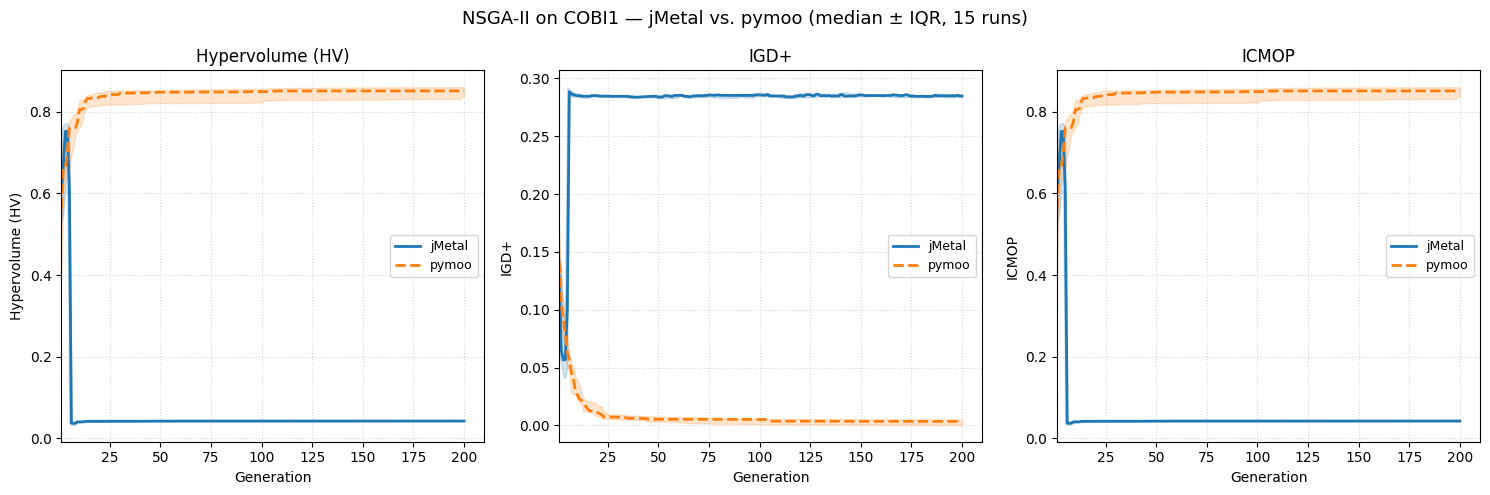

In [36]:
PI_COLS = ["hv", "igdPlus", "icmop"]
PI_LABELS = {"hv": "Hypervolume (HV)", "igdPlus": "IGD+", "icmop": "ICMOP"}
COLORS = {"jMetal": "#1f77b4", "pymoo": "#ff7f0e"}
STYLES = {"jMetal": "-", "pymoo": "--"}

# ── Cast numerics ─────────────────────────────────────────────────────────────
for df in [df_jmetal, df_pymoo]:
    for col in PI_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["gen"] = pd.to_numeric(df["gen"], errors="coerce").astype(int)
    df["run"] = pd.to_numeric(df["run"], errors="coerce").astype(int)

# ── Forward-fill missing generations per run ──────────────────────────────────
def forward_fill(df):
    max_gen = df["gen"].max()
    all_gens = pd.RangeIndex(1, max_gen + 1)
    filled = []
    for run in df["run"].unique():
        run_df = df[df["run"] == run].set_index("gen").reindex(all_gens)
        run_df[PI_COLS] = run_df[PI_COLS].ffill()
        run_df["run"] = run
        filled.append(run_df.reset_index().rename(columns={"index": "gen"}))
    return pd.concat(filled, ignore_index=True)

df_jmetal_filled = forward_fill(df_jmetal)
df_pymoo_filled  = forward_fill(df_pymoo)

# ── Summary statistics (median, Q25, Q75 per generation) ─────────────────────
def summary_stats(df, label):
    rows = []
    for gen, grp in df.groupby("gen"):
        row = {"gen": gen, "implementation": label}
        for pi in PI_COLS:
            vals = grp[pi].dropna()
            row[f"{pi}_median"] = np.median(vals)
            row[f"{pi}_q25"]    = np.percentile(vals, 25)
            row[f"{pi}_q75"]    = np.percentile(vals, 75)
        rows.append(row)
    return pd.DataFrame(rows)

df_stats = pd.concat([
    summary_stats(df_jmetal_filled, "jMetal"),
    summary_stats(df_pymoo_filled,  "pymoo"),
], ignore_index=True)

# ── Three plots: one per performance indicator ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, pi in zip(axes, PI_COLS):
    for impl, grp in df_stats.groupby("implementation"):
        grp = grp.sort_values("gen")
        ax.plot(grp["gen"], grp[f"{pi}_median"],
                color=COLORS[impl], linestyle=STYLES[impl],
                linewidth=2, label=impl)
        ax.fill_between(grp["gen"], grp[f"{pi}_q25"], grp[f"{pi}_q75"],
                        color=COLORS[impl], alpha=0.2)
    ax.set_title(PI_LABELS[pi], fontsize=12)
    ax.set_xlabel("Generation", fontsize=10)
    ax.set_ylabel(PI_LABELS[pi], fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_xlim(left=1)

fig.suptitle("NSGA-II on COBI1 — jMetal vs. pymoo (median ± IQR, 15 runs)", fontsize=13)
plt.tight_layout()
plt.savefig("nsga-ii_cobi1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

This use case showed how the COMON knowledge base can be used to compare two implementations of the same algorithm. Starting from the NSGA-II algorithm specification, we retrieved both implementations (jMetal and pymoo) with a single SPARQL query. The metadata confirmed that both were run under identical experimental conditions on the COBI1 problem, so any difference in the results can be attributed to the implementation itself.

The two datasets use different log levels, which required aligning the data at generation granularity before comparing. This alignment was done directly in SPARQL. Since only improvements are logged, some generations are missing. We filled these gaps by carrying the last recorded value forward, and then computed the median and interquartile range across 15 runs for three performance indicators: HV, IGD+, and ICMOP.